---

We study the iVi (integrated variance implicit) scheme
of [Abi Jaber (2025)](https://arxiv.org/abs/2412.11264) for the Heston model.

---

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [101]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from ivi_scheme import ivi_scheme, impvol_heston_ivi_scheme
from heston import impvol_heston_charfunc
from utils import black_otm_impvol_mc

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

## The iVi scheme

In [3]:
case_1 = {"V0": 0.006, "a": 17.25 * 0.018, "b": -17.25, "c": 2.95, "rho": -0.68}
case_2 = {"V0": 0.023, "a": 2.15 * 0.057, "b": -2.15, "c": 0.86, "rho": -0.70}
case_3 = {"V0": 0.04, "a": 0.5 * 0.04, "b": -0.5, "c": 1.0, "rho": -0.90}

In [56]:
n_disc = 10
n_paths = 10**5
T = 0.1

V, U, Z, ts = ivi_scheme(
    T=T,
    a=case_1["a"],
    b=case_1["b"],
    c=case_1["c"],
    V0=case_1["V0"],
    n_disc=n_disc,
    n_paths=n_paths,
    seed=SEED,
)

In [81]:
ks = np.linspace(-0.5, 0.1, 101)

In [98]:
np.random.seed(SEED)

S0 = 1.0
S = S0 * np.ones(n_paths)
log_S = np.log(S)

normal = np.random.normal(size=(n_disc, n_paths))

rho = case_1["rho"]
rho_bar = np.sqrt(1.0 - rho**2)

log_S = np.log(S0) + (
    -0.5 * U.sum(axis=0)
    + rho * Z.sum(axis=0)
    + rho_bar * (np.sqrt(U) * normal).sum(axis=0)
)
S_mc = np.exp(log_S)

impvols_hst_ivi = np.asarray(black_otm_impvol_mc(S=S_mc, k=ks, T=T))

In [105]:
params_heston = {
    "v": case_1["V0"],
    "lbd": -case_1["b"],
    "vbar": -case_1["a"] / case_1["b"],
    "nu": case_1["c"],
    "rho": case_1["rho"],
}

In [ ]:
impvols_hst_cf = impvol_heston_charfunc(ks, T, params_heston)

In [103]:
impvols_hst_ivi = impvol_heston_ivi_scheme(
    ks, T, params_heston, n_disc=n_disc, n_paths=n_paths, seed=SEED
)

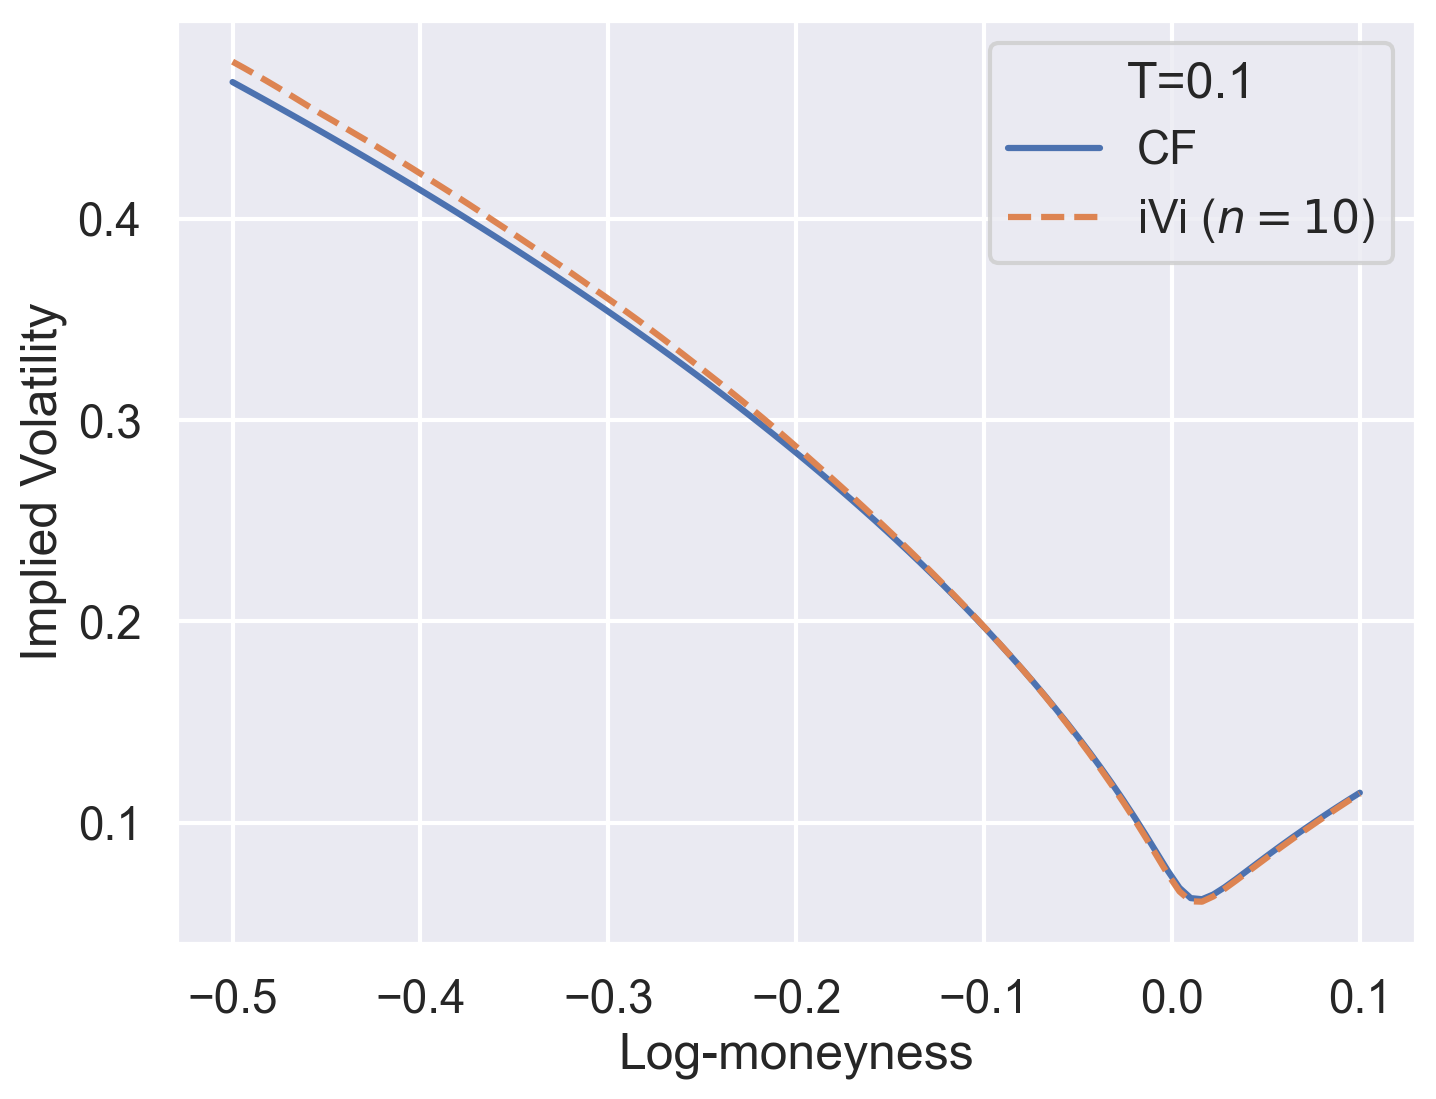

In [104]:
fig, ax = plt.subplots()
ax.plot(ks, impvols_hst_cf, label="CF")
ax.plot(ks, impvols_hst_ivi, "--", label=rf"iVi ($n={n_disc}$)")
ax.legend(title=f"T={T}")
ax.set_xlabel(r"Log-moneyness")
ax.set_ylabel("Implied Volatility")
plt.show()